# Randy Vásquez: Pitch Mix

Whiff%, xwOBA against, usage, and Pitching+ by year. Numbers as of August 2026, stored in `vasquez_hand_entered_values_2026.csv`. Run top to bottom from this folder.

In [1]:
import matplotlib.pyplot as plt

brown = "#5b3617"
gold = "#c9a227"
plt.rcParams.update({'font.size': 12})

## 1. Load values

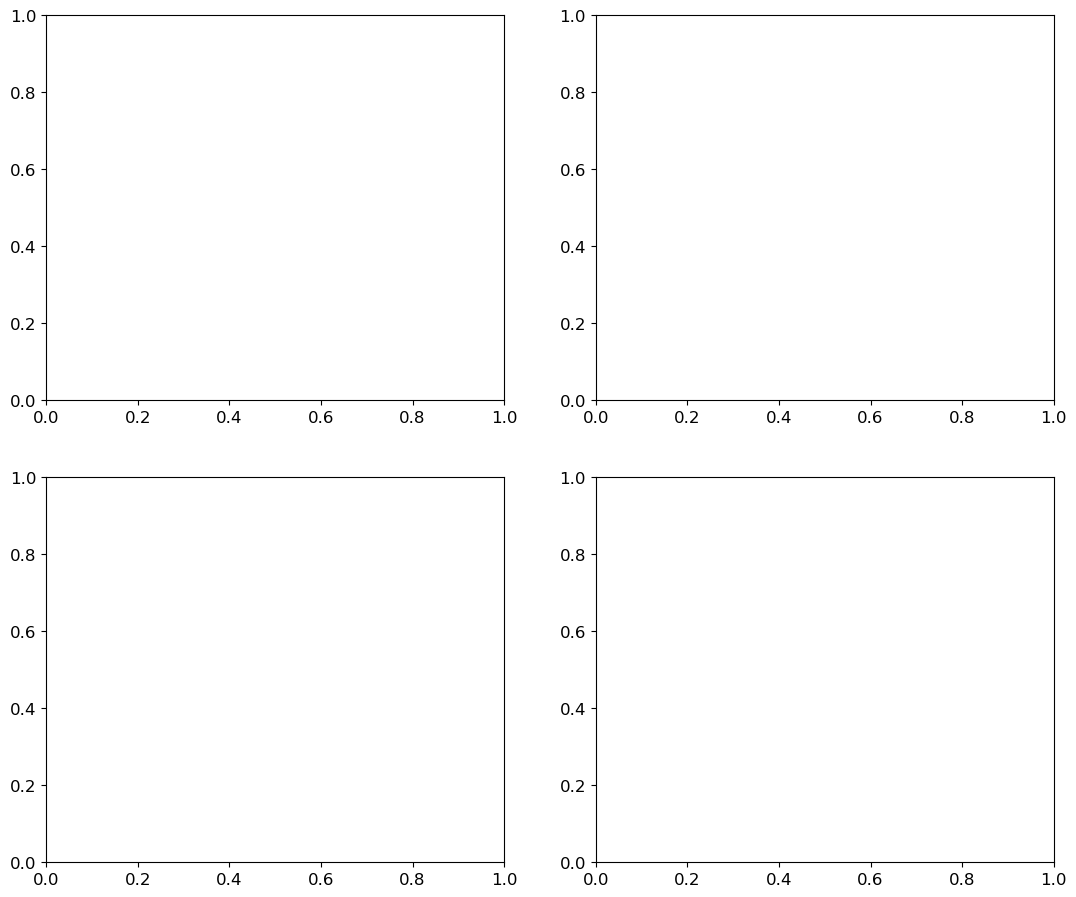

In [2]:
import pandas as pd

# Numbers as of August 2026, typed in from FanGraphs and Baseball Savant
hv = pd.read_csv("vasquez_hand_entered_values_2026.csv", dtype={"label": str})
get = lambda m: hv[hv["metric"] == m]
whiff_bench = get("benchmark").set_index("label").loc["whiff", "value"]
xwoba_bench = get("benchmark").set_index("label").loc["xwoba", "value"]

pitches_whiff, whiff_vals = get("whiff")["label"].tolist(), get("whiff")["value"].tolist()
pitches_xwoba, xwoba_vals = get("xwoba")["label"].tolist(), get("xwoba")["value"].tolist()
usage_vals = get("usage").set_index("label").loc[pitches_whiff, "value"].tolist()     # same order as the whiff panel

years, pitching_plus = get("pitching_plus")["label"].tolist(), [int(v) for v in get("pitching_plus")["value"]]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

## 2. Build the four panels

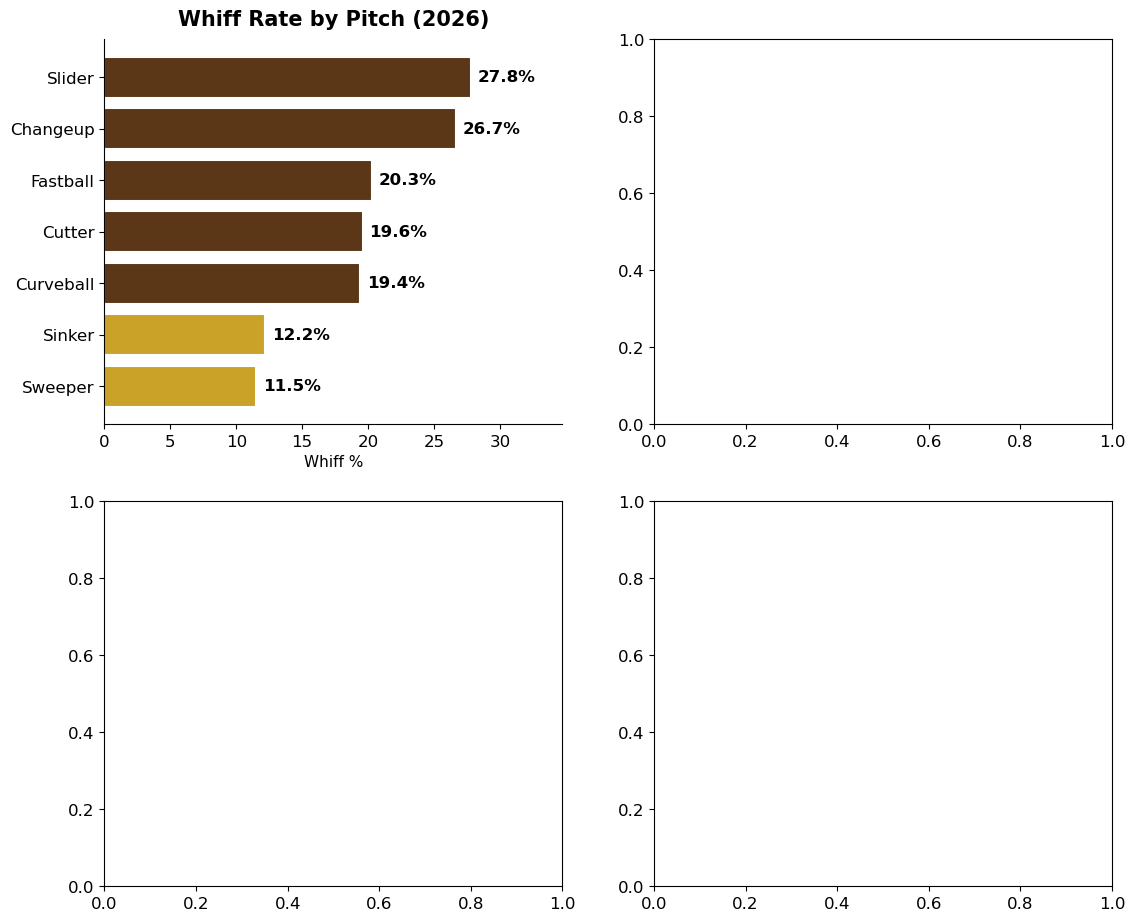

In [3]:
ax1 = axes[0][0]
colors1 = [brown if v >= whiff_bench else gold for v in whiff_vals]
bars1 = ax1.barh(pitches_whiff, whiff_vals, color=colors1, edgecolor='white', linewidth=1.5)
ax1.set_title("Whiff Rate by Pitch (2026)", fontsize=15, fontweight="bold", pad=10)
ax1.set_xlabel("Whiff %", fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xlim(0, max(whiff_vals) * 1.25)
for bar, val in zip(bars1, whiff_vals):
    ax1.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}%", va='center', fontsize=12, fontweight='bold')

fig

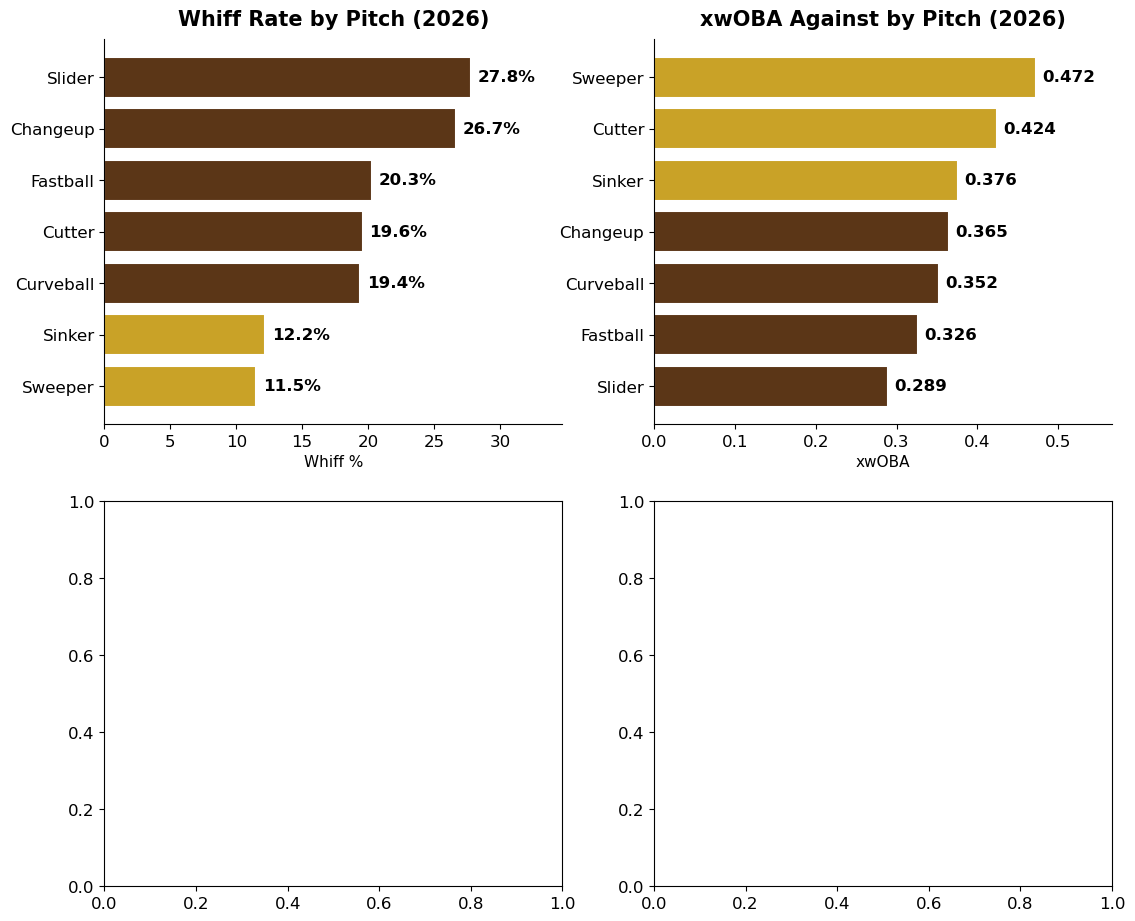

In [4]:
ax2 = axes[0][1]
colors2 = [brown if v <= xwoba_bench else gold for v in xwoba_vals]
bars2 = ax2.barh(pitches_xwoba, xwoba_vals, color=colors2, edgecolor='white', linewidth=1.5)
ax2.set_title("xwOBA Against by Pitch (2026)", fontsize=15, fontweight="bold", pad=10)
ax2.set_xlabel("xwOBA", fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_xlim(0, max(xwoba_vals) * 1.2)
for bar, val in zip(bars2, xwoba_vals):
    ax2.text(val+0.008, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va='center', fontsize=12, fontweight='bold')

fig

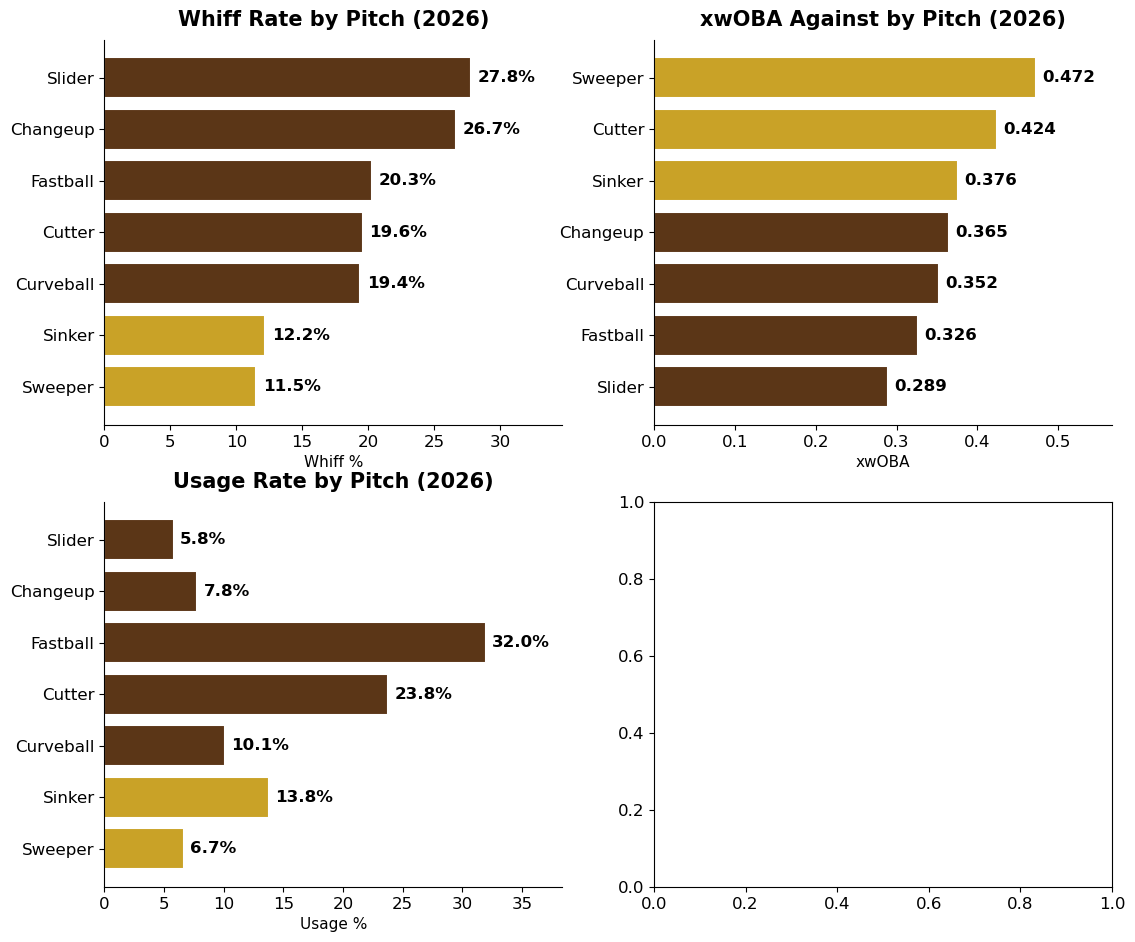

In [5]:
ax3 = axes[1][0]
colors3 = [brown if v >= whiff_bench else gold for v in whiff_vals]
bars3 = ax3.barh(pitches_whiff, usage_vals, color=colors3, edgecolor='white', linewidth=1.5)
ax3.set_title("Usage Rate by Pitch (2026)", fontsize=15, fontweight="bold", pad=10)
ax3.set_xlabel("Usage %", fontsize=11)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.set_xlim(0, max(usage_vals) * 1.2)
for bar, val in zip(bars3, usage_vals):
    ax3.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}%", va='center', fontsize=12, fontweight='bold')

fig

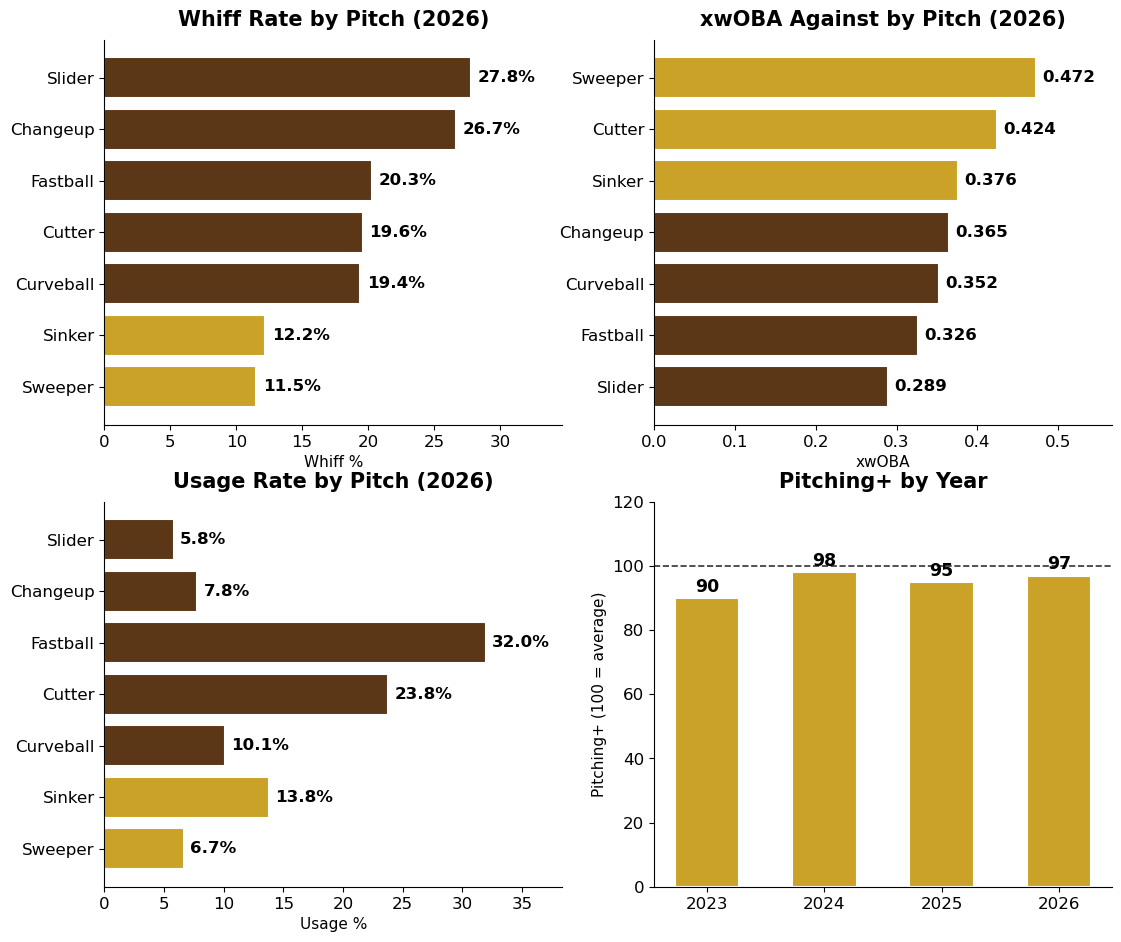

In [6]:
ax4 = axes[1][1]
colors4 = [brown if v >= 100 else gold for v in pitching_plus]
bars4 = ax4.bar(years, pitching_plus, color=colors4, width=0.55, edgecolor='white', linewidth=1.5)
ax4.axhline(100, color="#333333", linewidth=1.2, linestyle="--")
ax4.set_title("Pitching+ by Year", fontsize=15, fontweight="bold", pad=10)
ax4.set_ylabel("Pitching+ (100 = average)", fontsize=11)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.set_ylim(0, 120)
for bar, val in zip(bars4, pitching_plus):
    ax4.text(bar.get_x()+bar.get_width()/2, val+2, str(val), ha='center', fontsize=12.5, fontweight='bold')

fig

## 3. Title, legend, save

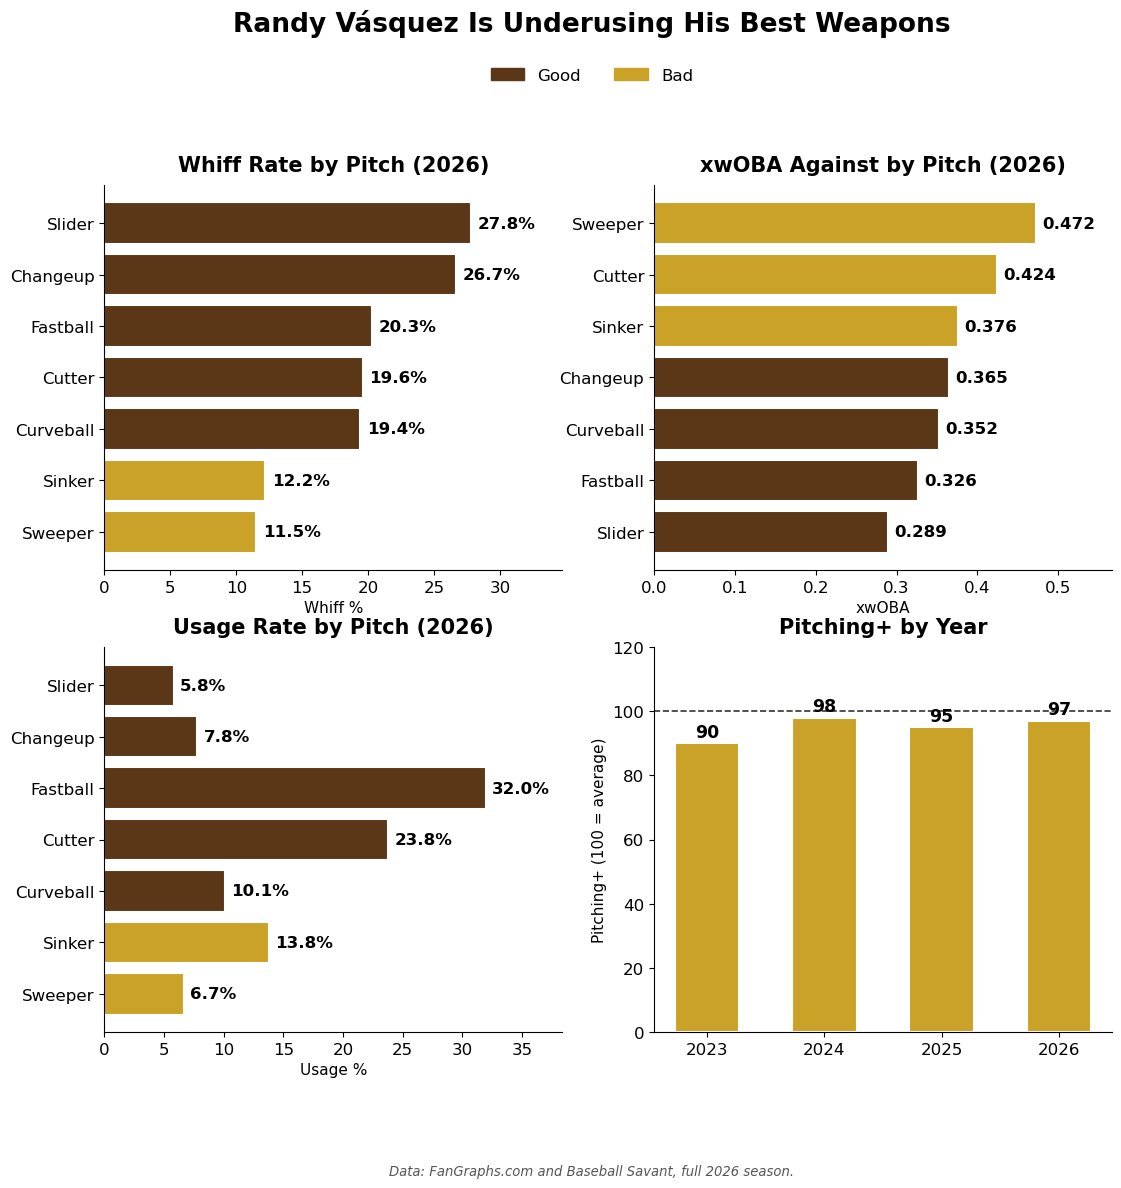

In [7]:
fig.suptitle("Randy Vásquez Is Underusing His Best Weapons", fontsize=19, fontweight="bold", y=1.04)

legend_elements = [
    plt.Rectangle((0,0),1,1, color=brown, label="Good"),
    plt.Rectangle((0,0),1,1, color=gold, label="Bad"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 1.0))

fig.text(0.5, -0.02, "Data: FanGraphs.com and Baseball Savant, full 2026 season.",
          ha="center", fontsize=9.5, style="italic", color="#555555")

fig.savefig("../figures/vasquez_pitch_mix_2026.png", dpi=200, bbox_inches="tight", facecolor="white")
fig